In [8]:
import xarray as xr
import numpy as np
import importlib.util
from pathlib import Path

#run from the repo root 
root = Path.cwd()
if root.name == 'Scripts':
    root = root.parent

#local plotting functions
spec = importlib.util.spec_from_file_location('plot_init', root / 'functions' / 'plot_init.py')
plot_init = importlib.util.module_from_spec(spec)
spec.loader.exec_module(plot_init)

#plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import matplotlib.patheffects as path_effects


In [9]:
fn = root / 'externaldata' / 'GEBCO_2025.nc'
ds = xr.open_dataset(fn)
#slice to the region of interest
ds = ds.sel(lat=slice(45, 85), lon=slice(-180,-80))

#upscaling for plotting -- this is a regional figure 
xres = ds['lon'][1] - ds['lon'][0]
yres = ds['lat'][1] - ds['lat'][0]
scalefactor = 2 
xresnew = xres * scalefactor
yresnew = yres * scalefactor
xarr = np.arange(ds['lon'].min(), ds['lon'].max() + xresnew, xresnew)
yarr = np.arange(ds['lat'].min(), ds['lat'].max() + yresnew, yresnew)
ds = ds.interp(lon=xarr, lat=yarr, method='nearest')

lat,lon = ds['lat'].values, ds['lon'].values
ele = ds['elevation'].values  # Elevation is negative below sea level


In [10]:
fn = root / 'Data' / 'climate.nc'
ds = xr.open_dataset(fn)
beau_hs = ds['beau_hs'].values
chuk_hs = ds['chuk_hs'].values
beau_wnd = ds['beau_wnd'].values
chuk_wnd = ds['chuk_wnd'].values
beau_ice = ds['beau_ice'].values
chuk_ice = ds['chuk_ice'].values


/var/folders/rm/238fvn_n5_52ycbcltyql4dh0000gp/T/ipykernel_25154/3270942453.py:162: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_chuk.plot(months + offset_hs, chuk_hs_median, '-', color=color_hs, linewidth=linewidth,
/var/folders/rm/238fvn_n5_52ycbcltyql4dh0000gp/T/ipykernel_25154/3270942453.py:164: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_chuk_wnd.plot(months + offset_wnd, chuk_wnd_median, '-', color=color_wnd, linewidth=linewidth,
/var/folders/rm/238fvn_n5_52ycbcltyql4dh0000gp/T/ipykernel_25154/3270942453.py:166: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_chuk_ice.plot(months + offset_ice, chuk_ice_me

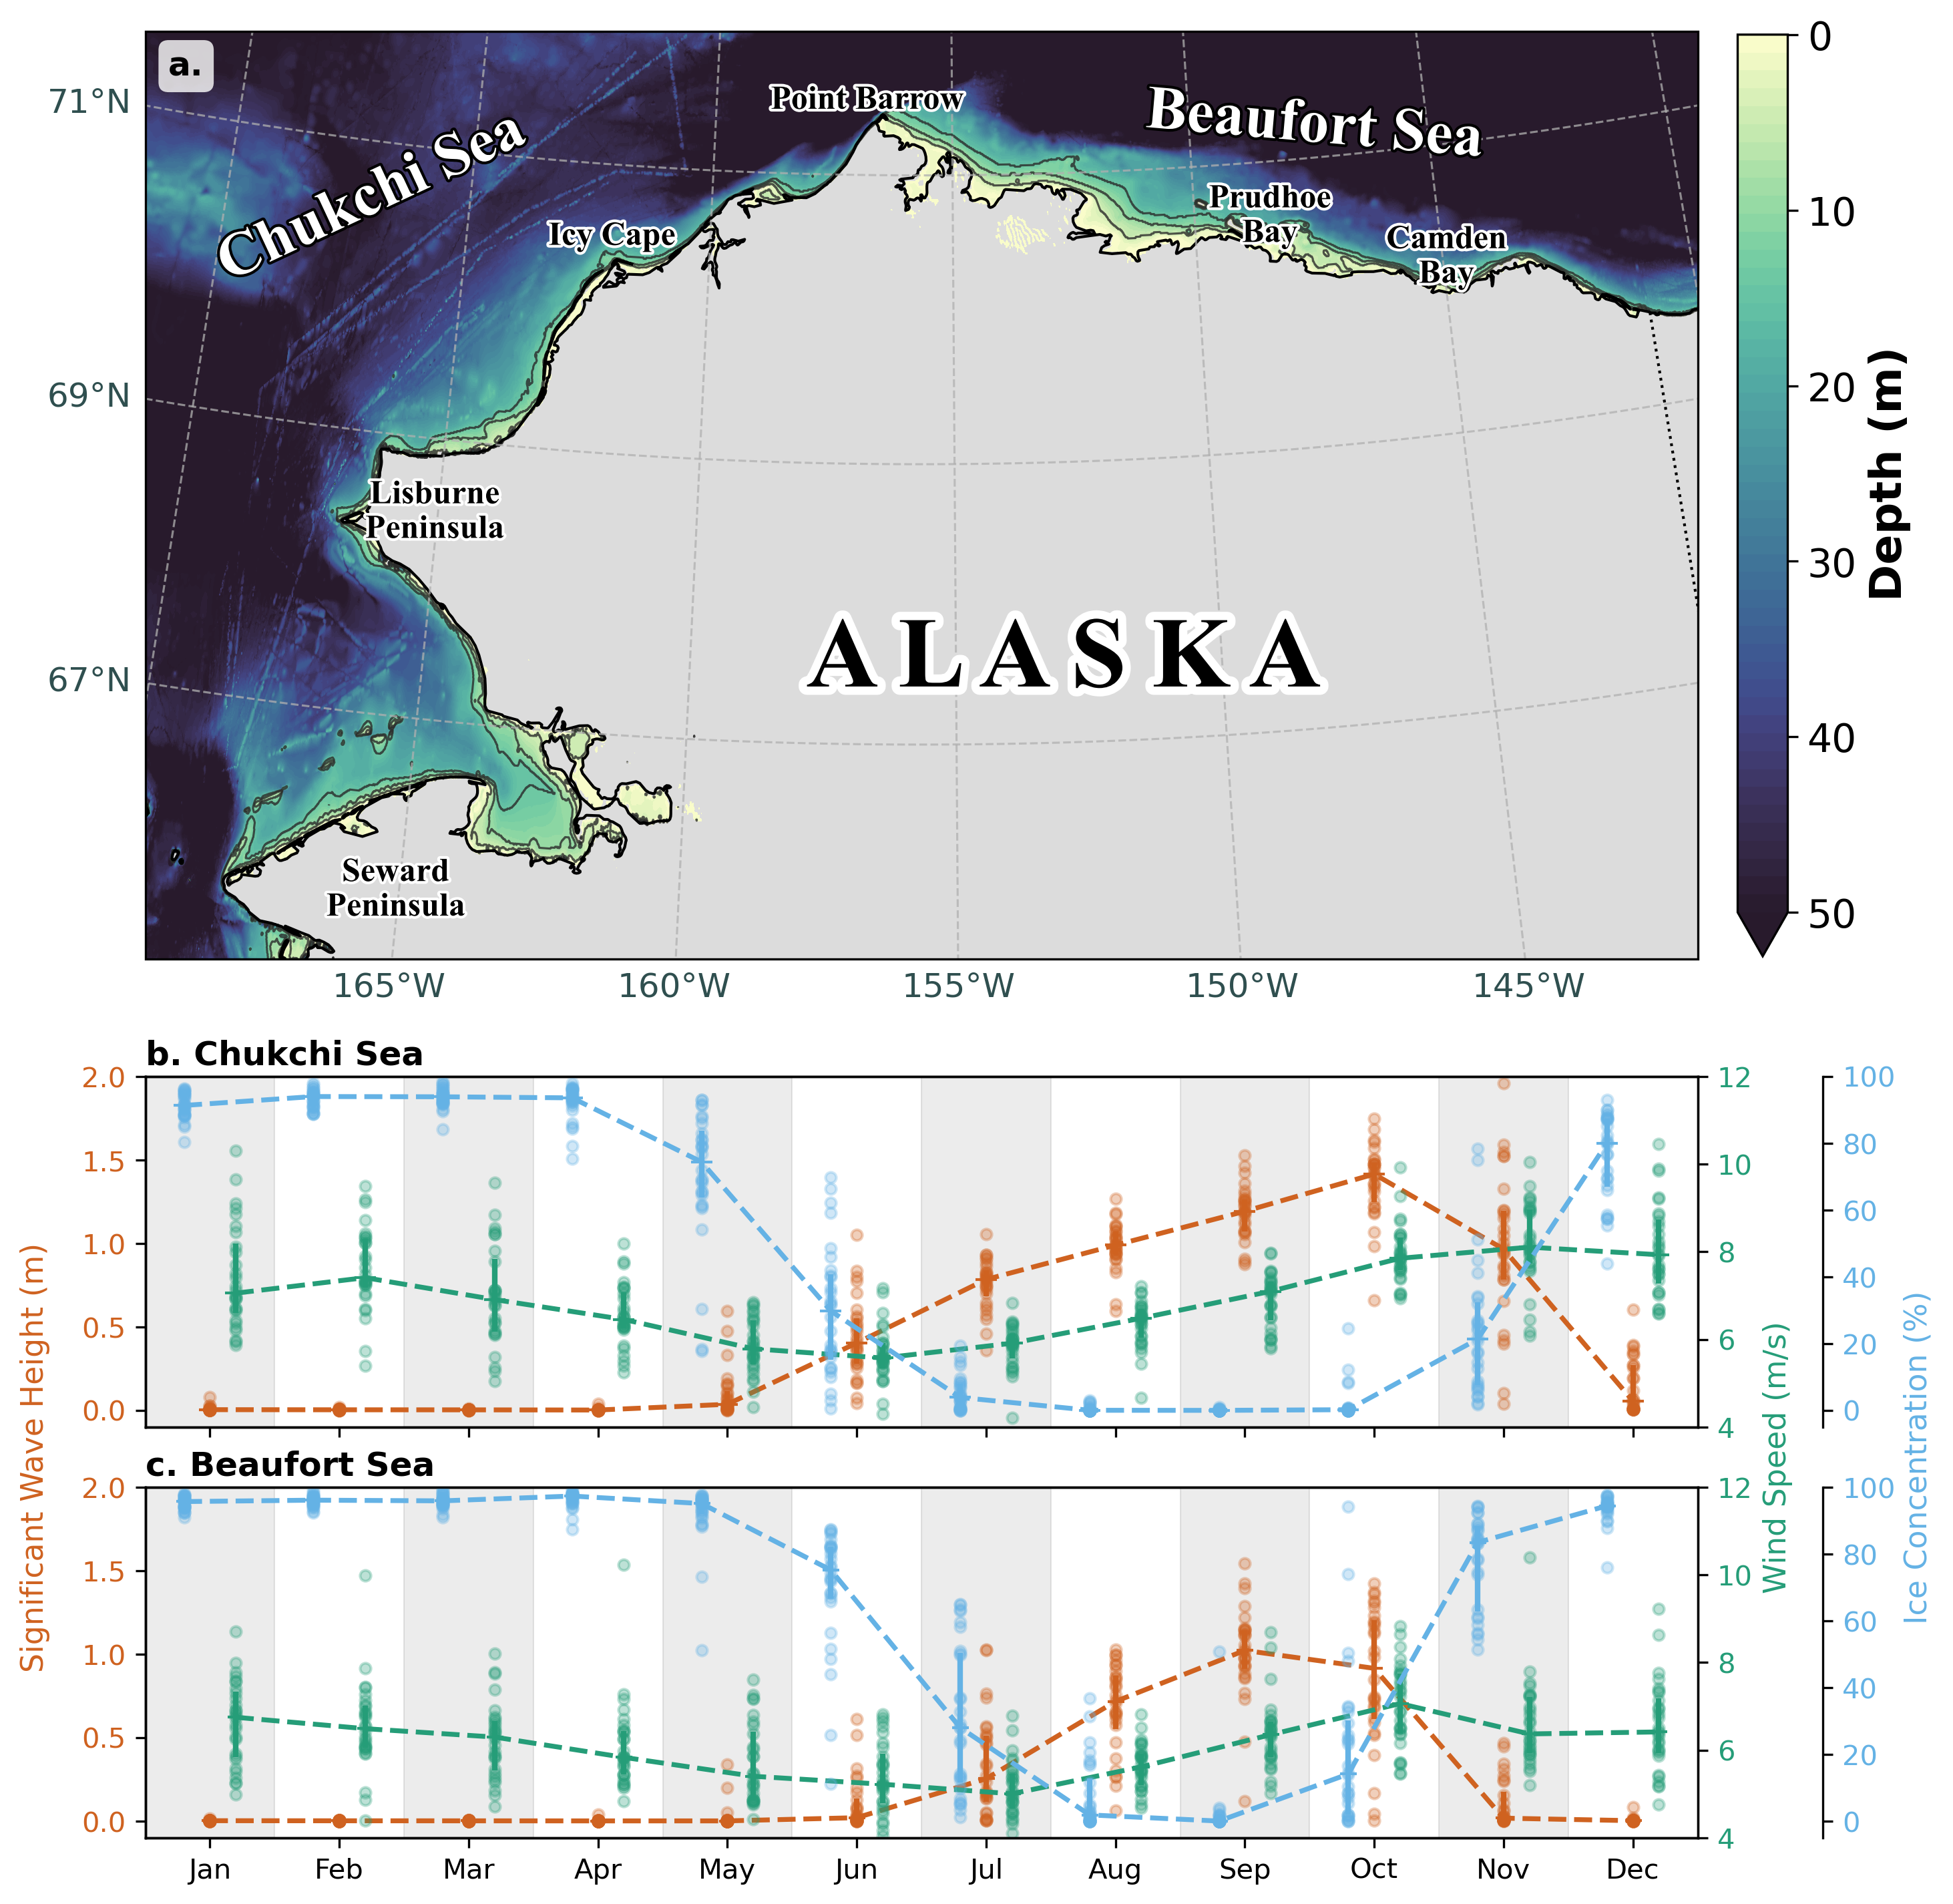

In [11]:

def place_label(ax, lon, lat, text, fontsize=12, fontcolor='white', 
                outline_color='black', outline_width=2, rotation=0, 
                weight='normal', style='normal', ha='left', va='bottom'):
    txt = ax.text(lon, lat, text, transform=ccrs.PlateCarree(),
                  fontsize=fontsize, color=fontcolor, weight=weight,
                  style=style, ha=ha, va=va, rotation=rotation,
                  family='Times New Roman') 
    if outline_color and outline_width > 0:
        txt.set_path_effects([
            path_effects.Stroke(linewidth=outline_width, foreground=outline_color),
            path_effects.Normal()
        ])
    
    return txt

def make_it_nice(ax,extent,shapes=None):
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor='gainsboro')
    ax.coastlines(resolution='10m', color='k', linewidth=1)
    ax.set_facecolor('gainsboro')

def get_gridlines(ax):
    xticks = np.arange(-170, 190, 5)
    yticks = np.arange(55, 83, 2)
    gl = ax.gridlines(draw_labels=True, linestyle='--',
                      xlocs=xticks, ylocs=yticks, alpha=0.75,
                      x_inline=False, y_inline=False,
                      zorder=50, linewidth=0.75,
                      xpadding=10)
    return gl

def gl_styler(gl,l=False,r=False,t=False,b=False):
    gl.bottom_labels = b
    gl.top_labels = t
    gl.right_labels = r
    gl.left_labels = l
    gl.xlabel_style = {'size': 12, 'rotation': 0, 'color': 'darkslategrey','ha':'center'}  # <-- Add pad here
    gl.ylabel_style = {'size': 12, 'rotation': 0, 'color': 'darkslategrey'} 

def plot_grid(ax,x,y,depth):
    levels = np.linspace(-50, 0, num=50)
    cmap = cmocean.cm.deep_r
    ax.set_rasterization_zorder(0)
    cf = ax.contourf(x, y, depth, levels=levels, cmap=cmap,
                        extend='min', zorder=-1)
    contour_levels = [-15, -10, -5]
    cs = ax.contour(x, y, depth, levels=contour_levels, 
                       colors='#2a2a2a', linewidths=0.75, alpha=0.8,
                       linestyles='solid', zorder=1)
    return cf, cs



#init figure
fig = plt.figure(figsize=(10, 10),dpi=300)
extent,rotation = plot_init.get_extent(option='main')
proj = plot_init.get_projection(extent, rotation=rotation)
xnew,ynew = plot_init.transform_coordinates(lon, lat, proj)

ax = fig.add_subplot(1,1,1, projection=proj)
ax.set_extent(extent, crs=ccrs.PlateCarree())
make_it_nice(ax, extent)
cf, cs = plot_grid(ax, xnew, ynew, ele)

cbar_ax = fig.add_axes([0.92, 0.265, 0.025, 0.46])  # [left, bottom, width, height]
cbar = plt.colorbar(cf, cax=cbar_ax, orientation='vertical')
cbar.set_label('Depth (m)', fontsize=16,fontweight='bold')
cbar.ax.tick_params(labelsize=14)
cbar.set_ticks(np.arange(-50, 10, 10))  # Set ticks at -50, -40, ..., 0
cbar.set_ticklabels([str(-tick) for tick in cbar.get_ticks()])

gl = get_gridlines(ax)
gl_styler(gl, l=True, b=True)



ax.text(0.015, 0.98, 'a.', transform=ax.transAxes, fontsize=12, 
        va='top', ha='left', weight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.8))

place_label(ax, -156.8, 71.4, 'Point Barrow', fontsize=12, ha='center', weight='bold', 
            outline_color='white', outline_width=2, fontcolor='black')
place_label(ax, -148.5, 70.4, 'Prudhoe\nBay', fontsize=12, ha='center', weight='bold', 
            outline_color='white', outline_width=2, fontcolor='black')
place_label(ax, -145, 70, 'Camden\nBay', fontsize=12, ha='center', weight='bold', 
            outline_color='white', outline_width=2, fontcolor='black')
place_label(ax, -162, 70.4, 'Icy Cape', fontsize=12, ha='center', weight='bold', 
            outline_color='white', outline_width=2, fontcolor='black')
place_label(ax, -165, 68.25, 'Lisburne\nPeninsula', fontsize=12, ha='center', weight='bold', 
            outline_color='white', outline_width=2, fontcolor='black')
place_label(ax, -165, 65.5, 'Seward\nPeninsula', fontsize=12, ha='center', fontcolor='black', 
            outline_color='white', outline_width=2, weight='bold')
place_label(ax, -170, 69.8, 'Chukchi Sea', fontsize=22, weight='bold', rotation=25)
place_label(ax, -151, 71, 'Beaufort Sea', weight='bold', rotation=-5, fontsize=22)
place_label(ax, -153, 67.25, 'A L A S K A', fontsize=36, fontcolor='black', 
            outline_color='white', weight='bold', ha='center', outline_width=6)

#
# ______________________________ Regional Climatology ________________
#
x0,y0 = 0.125, -0.175
dy,dx = 0.175,0.775
offset = 0.03
ax_inset1 = fig.add_axes([x0, y0, dx, dy])
ax_inset2 = fig.add_axes([x0, y0 + dy + offset, dx, dy], sharex=ax_inset1)

# Calculate medians and quartiles for each region
chuk_hs_median = np.nanmedian(chuk_hs, axis=0)
chuk_hs_q25 = np.nanpercentile(chuk_hs, 25, axis=0)
chuk_hs_q75 = np.nanpercentile(chuk_hs, 75, axis=0)

chuk_wnd_median = np.nanmedian(chuk_wnd, axis=0)
chuk_wnd_q25 = np.nanpercentile(chuk_wnd, 25, axis=0)
chuk_wnd_q75 = np.nanpercentile(chuk_wnd, 75, axis=0)

chuk_ice_median = np.nanmedian(chuk_ice, axis=0) * 100
chuk_ice_q25 = np.nanpercentile(chuk_ice, 25, axis=0) * 100
chuk_ice_q75 = np.nanpercentile(chuk_ice, 75, axis=0) * 100

beau_hs_median = np.nanmedian(beau_hs, axis=0)
beau_hs_q25 = np.nanpercentile(beau_hs, 25, axis=0)
beau_hs_q75 = np.nanpercentile(beau_hs, 75, axis=0)

beau_wnd_median = np.nanmedian(beau_wnd, axis=0)
beau_wnd_q25 = np.nanpercentile(beau_wnd, 25, axis=0)
beau_wnd_q75 = np.nanpercentile(beau_wnd, 75, axis=0)

beau_ice_median = np.nanmedian(beau_ice, axis=0) * 100
beau_ice_q25 = np.nanpercentile(beau_ice, 25, axis=0) * 100
beau_ice_q75 = np.nanpercentile(beau_ice, 75, axis=0) * 100

months = np.arange(1, 13)
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Define colors
color_hs = '#CF6220'  # Orange/brown for wave height
color_wnd = '#259D78'  # Green for wind
color_ice = '#64B2E5'  # Blue for ice


#chukchi init
ax_chuk = ax_inset2
ax_chuk_wnd = ax_chuk.twinx()
ax_chuk_ice = ax_chuk.twinx()
ax_chuk_ice.spines['right'].set_position(('outward', 45))


#define offsets
offset_hs = 0
offset_wnd = 0.2
offset_ice = -0.2

#plot individual years with a little random offset
for year_idx in range(chuk_hs.shape[0]):
    ax_chuk.scatter(months + offset_hs, chuk_hs[year_idx, :], s=15, alpha=0.3, color=color_hs, zorder=2)
    ax_chuk_wnd.scatter(months + offset_wnd, chuk_wnd[year_idx, :], s=15, alpha=0.3, color=color_wnd, zorder=2)
    ax_chuk_ice.scatter(months + offset_ice, chuk_ice[year_idx, :] * 100, s=15, alpha=0.3, color=color_ice, zorder=2)


linewidth = 1.75
linestyle = 'dashed'
ax_chuk.plot(months + offset_hs, chuk_hs_median, '-', color=color_hs, linewidth=linewidth, 
             linestyle=linestyle, label='Wave Height', zorder=3)
ax_chuk_wnd.plot(months + offset_wnd, chuk_wnd_median, '-', color=color_wnd, linewidth=linewidth,
                 linestyle=linestyle, label='Wind Speed', zorder=3)
ax_chuk_ice.plot(months + offset_ice, chuk_ice_median, '-', color=color_ice, linewidth=linewidth,
                 linestyle=linestyle, label='Ice Concentration', zorder=3)

#median and quartile 
capsize = 0
spanwidth = 2
markersize = 7.5
ax_chuk.errorbar(months + offset_hs, chuk_hs_median, 
                 yerr=[chuk_hs_median - chuk_hs_q25, chuk_hs_q75 - chuk_hs_median],
                 fmt='_', color=color_hs, markersize=markersize, capsize=capsize, linewidth=spanwidth, zorder=4)
ax_chuk_wnd.errorbar(months + offset_wnd, chuk_wnd_median,
                     yerr=[chuk_wnd_median - chuk_wnd_q25, chuk_wnd_q75 - chuk_wnd_median],
                     fmt='_', color=color_wnd, markersize=markersize, capsize=capsize, linewidth=spanwidth, zorder=4)
ax_chuk_ice.errorbar(months + offset_ice, chuk_ice_median,
                     yerr=[chuk_ice_median - chuk_ice_q25, chuk_ice_q75 - chuk_ice_median],
                     fmt='_', color=color_ice, markersize=markersize, capsize=capsize, linewidth=spanwidth, zorder=4)



ax_chuk.tick_params(axis='y', labelcolor=color_hs)
ax_chuk_wnd.tick_params(axis='y', labelcolor=color_wnd)
ax_chuk_ice.tick_params(axis='y', labelcolor=color_ice)

ax_chuk.set_ylim(-0.1, 2)
ax_chuk_wnd.set_ylim(4, 12)
ax_chuk_ice.set_ylim(-5, 100)

ax_chuk.set_xlim(0.5, 12.5)
ax_chuk.set_xticks([])
ax_chuk.tick_params(labelbottom=False)
ax_chuk.text(0, 1.015, 'b. Chukchi Sea', transform=ax_chuk.transAxes, 
             fontsize=12, va='bottom', weight='bold')

ax_beau = ax_inset1
ax_beau_wnd = ax_beau.twinx()
ax_beau_ice = ax_beau.twinx()
ax_beau_ice.spines['right'].set_position(('outward', 45))

#alternating month shading
for i in range(1, 13, 2):
    ax_beau.axvspan(i - 0.5, i + 0.5, facecolor='gray', alpha=0.15, zorder=0)
    ax_chuk.axvspan(i - 0.5, i + 0.5, facecolor='gray', alpha=0.15, zorder=0)

for i in range(1, 13, 1):
    ax_chuk.axvline(i + 0.5, color='gray', alpha=0.2, linewidth=0.5, zorder=1)
    ax_beau.axvline(i + 0.5, color='gray', alpha=0.2, linewidth=0.5, zorder=1)

#individual years as small dots with offsets
for year_idx in range(beau_hs.shape[0]):
    ax_beau.scatter(months + offset_hs, beau_hs[year_idx, :], s=15, alpha=0.3, color=color_hs, zorder=2)
    ax_beau_wnd.scatter(months + offset_wnd, beau_wnd[year_idx, :], s=15, alpha=0.3, color=color_wnd, zorder=2)
    ax_beau_ice.scatter(months + offset_ice, beau_ice[year_idx, :] * 100, s=15, alpha=0.3, color=color_ice, zorder=2)

#medians with dashed lines
ax_beau.plot(months + offset_hs, beau_hs_median, '-', color=color_hs, linewidth=linewidth,
             linestyle=linestyle, label='Wave Height', zorder=3)
ax_beau_wnd.plot(months + offset_wnd, beau_wnd_median, '-', color=color_wnd, linewidth=linewidth,
                 linestyle=linestyle, label='Wind Speed', zorder=3)
ax_beau_ice.plot(months + offset_ice, beau_ice_median, '-', color=color_ice, linewidth=linewidth,
                 linestyle=linestyle, label='Ice Concentration', zorder=3)

#median and quartile markers
ax_beau.errorbar(months + offset_hs, beau_hs_median,
                 yerr=[beau_hs_median - beau_hs_q25, beau_hs_q75 - beau_hs_median],
                 fmt='_', color=color_hs, markersize=6, capsize=0, linewidth=spanwidth, zorder=4)
ax_beau_wnd.errorbar(months + offset_wnd, beau_wnd_median,
                     yerr=[beau_wnd_median - beau_wnd_q25, beau_wnd_q75 - beau_wnd_median],
                     fmt='_', color=color_wnd, markersize=6, capsize=0, linewidth=spanwidth, zorder=4)
ax_beau_ice.errorbar(months + offset_ice, beau_ice_median,
                     yerr=[beau_ice_median - beau_ice_q25, beau_ice_q75 - beau_ice_median],
                     fmt='_', color=color_ice, markersize=6, capsize=0, linewidth=spanwidth, zorder=4)


ax_beau.tick_params(axis='y', labelcolor=color_hs)
ax_beau_wnd.tick_params(axis='y', labelcolor=color_wnd)
ax_beau_ice.tick_params(axis='y', labelcolor=color_ice)

ax_beau.set_ylim(-0.1, 2)
ax_beau_wnd.set_ylim(4, 12)
ax_beau_ice.set_ylim(-5, 100)

ax_beau.set_xlim(0.5, 12.5)
ax_beau.set_xticks(months)
ax_beau.set_xticklabels(month_labels)

ax_beau.text(0, 1.015, 'c. Beaufort Sea', transform=ax_beau.transAxes,
             fontsize=12, va='bottom', weight='bold')

#axis labels
label_y = y0 + dy + offset/2
fig.text(0.07, label_y, 'Significant Wave Height (m)', color=color_hs, fontsize=11, 
         rotation=90, va='center', ha='center')
fig.text(0.94, label_y, 'Wind Speed (m/s)', color=color_wnd, fontsize=11,
         rotation=90, va='center', ha='center')
fig.text(1.01, label_y, 'Ice Concentration (%)', color=color_ice, fontsize=11,
         rotation=90, va='center', ha='center')


plt.savefig(root / 'Figures' / 'bathymetry.png', 
            bbox_inches='tight', dpi=300)
plt.show()
